<a href="https://colab.research.google.com/github/neel20409/DataScience/blob/main/project06_linear_regression_scratch/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

print("✅ Imports done!")

✅ Imports done!


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [14]:
# Linear Regression formula:
# y_pred = X @ weights + bias
#
# Loss function (MSE):
# L = (1/n) * sum((y_pred - y_true)²)
#
# Gradient Descent updates:
# dL/dW = (2/n) * X.T @ (y_pred - y_true)
# dL/db = (2/n) * sum(y_pred - y_true)
#
# Update rule:
# weights = weights - learning_rate * dL/dW
# bias    = bias    - learning_rate * dL/db

print("📐 Linear Regression math:")
print("   Prediction: y = Xw + b")
print("   Loss:       MSE = mean((y_pred - y)²)")
print("   Update:     w = w - lr * gradient")

📐 Linear Regression math:
   Prediction: y = Xw + b
   Loss:       MSE = mean((y_pred - y)²)
   Update:     w = w - lr * gradient


In [15]:
class LinearRegressionScratch:
    """
    Linear Regression built from scratch using NumPy.
    Uses Gradient Descent to minimize MSE loss.
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.weights      = None
        self.bias         = None
        self.loss_history = []  # track loss every iteration

    def fit(self, X, y):
        """Train the model using gradient descent."""
        n_samples, n_features = X.shape

        # Initialize weights and bias to zero
        self.weights = np.zeros(n_features)
        self.bias    = 0.0

        # Gradient descent loop
        for i in range(self.n_iterations):

            # ── Forward pass: make predictions ──────────────────
            y_pred = self._predict(X)

            # ── Compute loss (MSE) ───────────────────────────────
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)

            # ── Compute gradients ────────────────────────────────
            error    = y_pred - y
            dw       = (2 / n_samples) * X.T @ error
            db       = (2 / n_samples) * np.sum(error)

            # ── Update weights and bias ──────────────────────────
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # Print progress every 100 iterations
            if (i + 1) % 100 == 0:
                print(f"  Iteration {i+1:4d}/{self.n_iterations} | Loss: {loss:.6f}")

        print(f"\n✅ Training complete! Final loss: {self.loss_history[-1]:.6f}")
        return self

    def _predict(self, X):
        """Internal predict — used during training."""
        return X @ self.weights + self.bias

    def predict(self, X):
        """Public predict — used after training."""
        return self._predict(X)

    def score(self, X, y):
        """R² score."""
        return r2_score(y, self.predict(X))

print("✅ LinearRegressionScratch class defined!")

✅ LinearRegressionScratch class defined!


In [16]:
# Load California Housing
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Simple feature engineering
X['RoomsPerPerson'] = X['AveRooms'] / X['AveOccup']
X['BedroomRatio']   = X['AveBedrms'] / X['AveRooms']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale — CRITICAL for gradient descent
# Without scaling, gradient descent diverges!
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}")
print(f"Test:  {X_test_sc.shape}")
print("\n✅ Data ready!")

Train: (16512, 10)
Test:  (4128, 10)

✅ Data ready!


In [17]:
# Train our scratch model
model = LinearRegressionScratch(
    learning_rate=0.01,
    n_iterations=1000
)

print("🚀 Training Linear Regression from scratch...\n")
model.fit(X_train_sc, y_train)

# Evaluate
train_r2 = model.score(X_train_sc, y_train)
test_r2  = model.score(X_test_sc, y_test)
test_mse = mean_squared_error(y_test, model.predict(X_test_sc))

print(f"\n📊 Results:")
print(f"   Train R²: {train_r2:.4f}")
print(f"   Test R²:  {test_r2:.4f}")
print(f"   Test MSE: {test_mse:.4f}")
print(f"   Test RMSE: {np.sqrt(test_mse):.4f}")

🚀 Training Linear Regression from scratch...

  Iteration  100/1000 | Loss: 0.681460
  Iteration  200/1000 | Loss: 0.524416
  Iteration  300/1000 | Loss: 0.497944
  Iteration  400/1000 | Loss: 0.486279
  Iteration  500/1000 | Loss: 0.479164
  Iteration  600/1000 | Loss: 0.474182
  Iteration  700/1000 | Loss: 0.470489
  Iteration  800/1000 | Loss: 0.467678
  Iteration  900/1000 | Loss: 0.465506
  Iteration 1000/1000 | Loss: 0.463812

✅ Training complete! Final loss: 0.463812

📊 Results:
   Train R²: 0.6530
   Test R²:  0.6447
   Test MSE: 0.4655
   Test RMSE: 0.6823


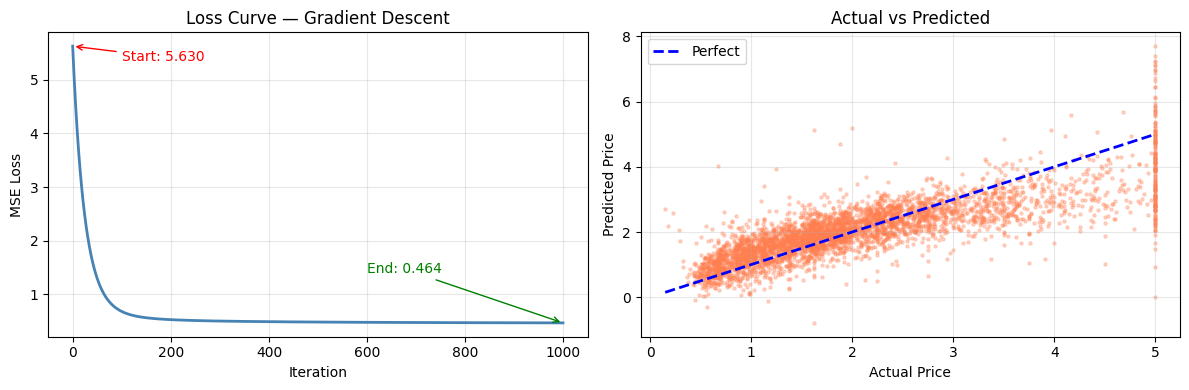

In [18]:
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(model.loss_history, color='steelblue', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Loss Curve — Gradient Descent")
plt.grid(True, alpha=0.3)

# Annotate key points
plt.annotate(f'Start: {model.loss_history[0]:.3f}',
             xy=(0, model.loss_history[0]),
             xytext=(100, model.loss_history[0]*0.95),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red')
plt.annotate(f'End: {model.loss_history[-1]:.3f}',
             xy=(len(model.loss_history)-1, model.loss_history[-1]),
             xytext=(len(model.loss_history)*0.6, model.loss_history[-1]*3),
             arrowprops=dict(arrowstyle='->', color='green'),
             color='green')

# Actual vs Predicted
plt.subplot(1, 2, 2)
y_pred = model.predict(X_test_sc)
plt.scatter(y_test, y_pred, alpha=0.3, color='coral', s=5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'b--', lw=2, label='Perfect')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

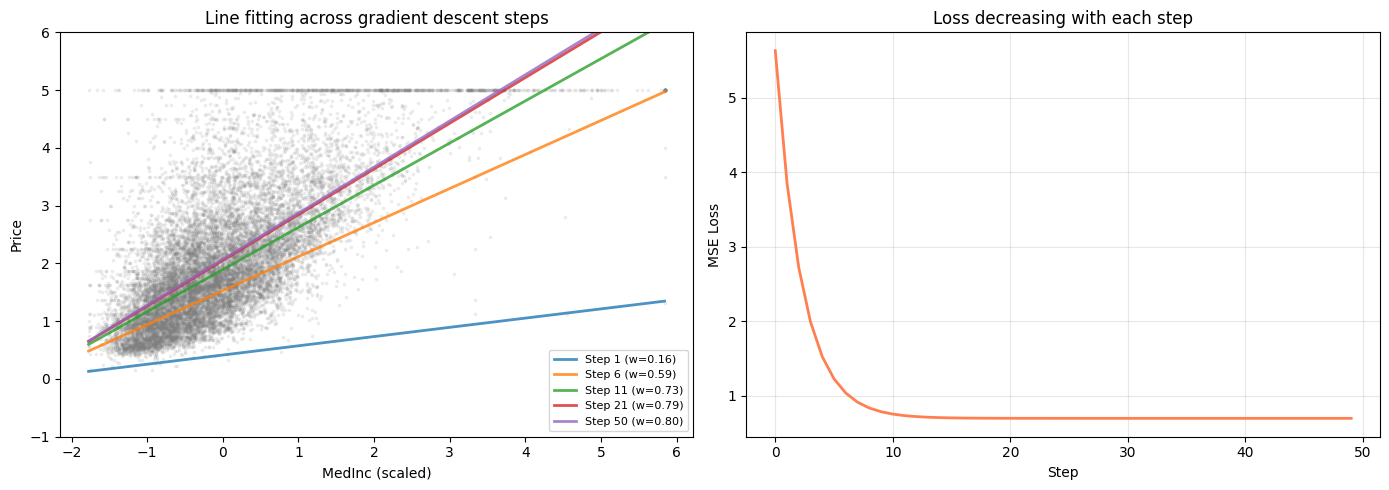

In [19]:
# Show gradient descent on a simple 1-feature problem
# Use only MedInc (most correlated with price)

X_simple = X_train_sc[:, 0].reshape(-1, 1)  # MedInc only
y_simple  = y_train

# Train simple model and record weight at each step
class LinearRegressionViz:
    def __init__(self, lr=0.1, n_iter=50):
        self.lr     = lr
        self.n_iter = n_iter
        self.w_history = []
        self.b_history = []
        self.l_history = []

    def fit(self, X, y):
        w, b = 0.0, 0.0
        n    = len(y)
        for _ in range(self.n_iter):
            pred  = X.flatten() * w + b
            error = pred - y
            dw    = (2/n) * np.dot(X.flatten(), error)
            db    = (2/n) * np.sum(error)
            w    -= self.lr * dw
            b    -= self.lr * db
            self.w_history.append(w)
            self.b_history.append(b)
            self.l_history.append(np.mean(error**2))
        self.w, self.b = w, b

viz_model = LinearRegressionViz(lr=0.1, n_iter=50)
viz_model.fit(X_simple, y_simple)

# Plot gradient descent steps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line fitting over iterations
x_line = np.linspace(X_simple.min(), X_simple.max(), 100)
axes[0].scatter(X_simple, y_simple, alpha=0.1, color='gray', s=3)

for step in [0, 5, 10, 20, 49]:
    w = viz_model.w_history[step]
    b = viz_model.b_history[step]
    y_line = x_line * w + b
    axes[0].plot(x_line, y_line,
                 label=f'Step {step+1} (w={w:.2f})',
                 linewidth=2, alpha=0.8)

axes[0].set_xlabel("MedInc (scaled)")
axes[0].set_ylabel("Price")
axes[0].set_title("Line fitting across gradient descent steps")
axes[0].legend(fontsize=8)
axes[0].set_ylim(-1, 6)

# Loss over steps
axes[1].plot(viz_model.l_history, color='coral', linewidth=2)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title("Loss decreasing with each step")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

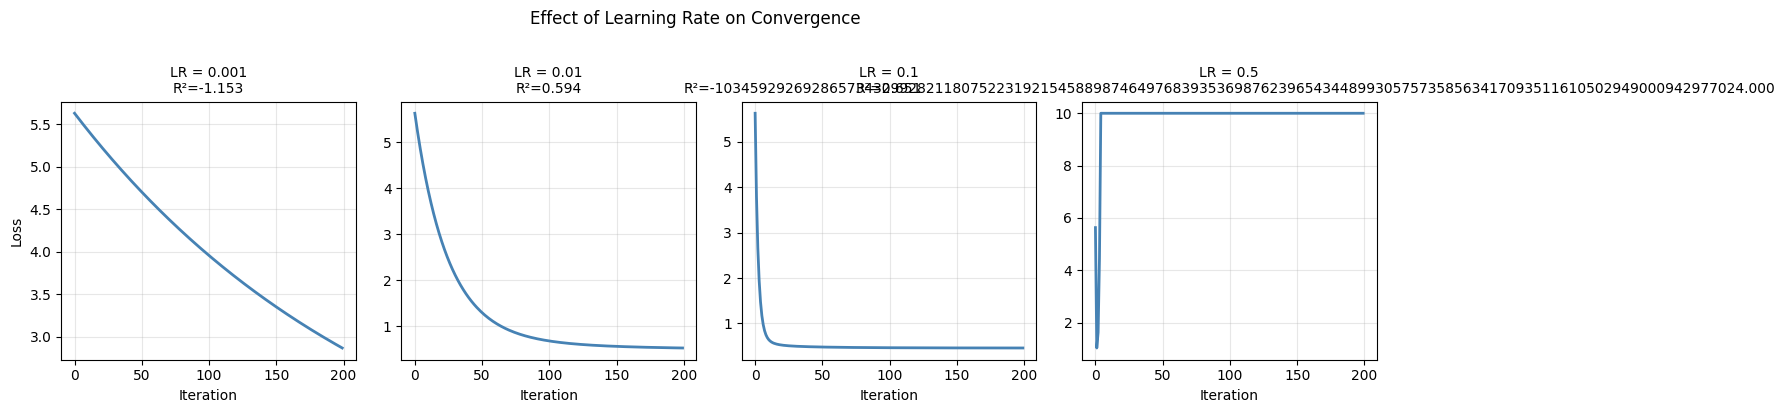

In [20]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
plt.figure(figsize=(14, 4))

for i, lr in enumerate(learning_rates):
    m = LinearRegressionScratch(learning_rate=lr, n_iterations=200)

    try:
        # Suppress print during training
        import io, sys
        old_stdout = sys.stdout
        sys.stdout = io.StringIO()
        m.fit(X_train_sc, y_train)
        sys.stdout = old_stdout

        # Cap loss for visualization
        losses = [min(l, 10) for l in m.loss_history]
        plt.subplot(1, 4, i+1)
        plt.plot(losses, linewidth=2, color='steelblue')
        r2 = m.score(X_test_sc, y_test)
        plt.title(f"LR = {lr}\nR²={r2:.3f}", fontsize=10)
        plt.xlabel("Iteration")
        if i == 0: plt.ylabel("Loss")
        plt.grid(True, alpha=0.3)
    except:
        sys.stdout = old_stdout
        plt.subplot(1, 4, i+1)
        plt.text(0.5, 0.5, 'Diverged!',
                 ha='center', va='center',
                 transform=plt.gca().transAxes,
                 color='red', fontsize=14)
        plt.title(f"LR = {lr}", fontsize=10)

plt.suptitle("Effect of Learning Rate on Convergence", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

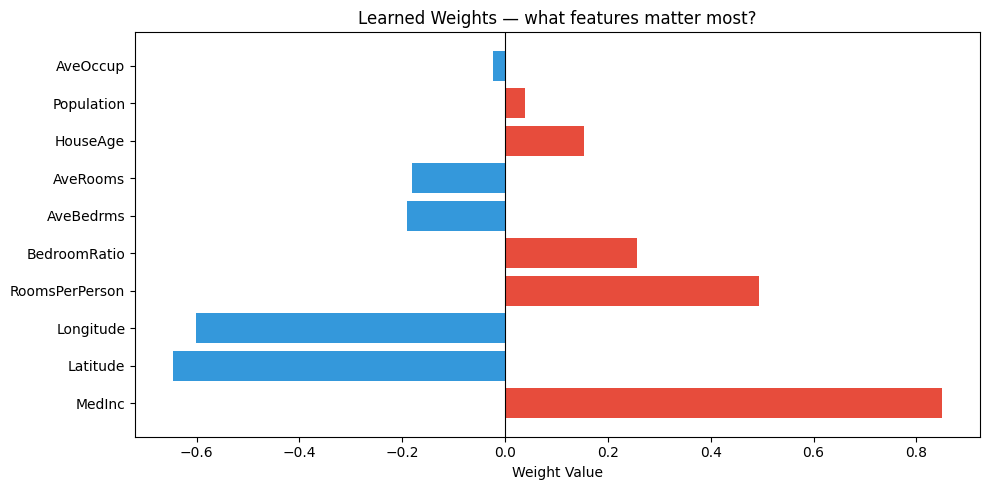


📋 Feature weights:
       Feature    Weight
        MedInc  0.848839
      Latitude -0.644957
     Longitude -0.600557
RoomsPerPerson  0.494132
  BedroomRatio  0.257311
     AveBedrms -0.190263
      AveRooms -0.181149
      HouseAge  0.154000
    Population  0.038537
      AveOccup -0.023056

Bias term: 2.0719


In [21]:
# What did the model learn?
feature_names = list(X.columns)
weights_df = pd.DataFrame({
    'Feature':  feature_names,
    'Weight':   model.weights,
    'Abs_Weight': np.abs(model.weights)
}).sort_values('Abs_Weight', ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if w > 0 else '#3498db' for w in weights_df['Weight']]
plt.barh(weights_df['Feature'], weights_df['Weight'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel("Weight Value")
plt.title("Learned Weights — what features matter most?")
plt.tight_layout()
plt.show()

print("\n📋 Feature weights:")
print(weights_df[['Feature','Weight']].to_string(index=False))
print(f"\nBias term: {model.bias:.4f}")

In [23]:
from sklearn.linear_model import LinearRegression as SklearnLR

# Train scikit-learn model first
sk_model = SklearnLR()
sk_model.fit(X_train_sc, y_train)

# New house as DataFrame with correct column names
new_house = pd.DataFrame([[
    5.0,    # MedInc
    20.0,   # HouseAge
    6.0,    # AveRooms
    1.2,    # AveBedrms
    1500.0, # Population
    3.0,    # AveOccup
    34.0,   # Latitude
    -118.0, # Longitude
    2.0,    # RoomsPerPerson
    0.2,    # BedroomRatio
]], columns=X_train.columns)  # ← uses same column names as training

# Scale
new_scaled = scaler.transform(new_house)

# Predict
predicted    = model.predict(new_scaled)[0]
sk_predicted = sk_model.predict(new_scaled)[0]

print("🏠 Prediction on new house:")
print(f"   Our model:    ${predicted * 100_000:,.0f}")
print(f"   Scikit-learn: ${sk_predicted * 100_000:,.0f}")
print(f"   Difference:   ${abs(predicted - sk_predicted) * 100_000:,.0f}")

🏠 Prediction on new house:
   Our model:    $235,380
   Scikit-learn: $234,105
   Difference:   $1,275
